# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [45]:
#Based on the Materials and Methods section of the paper, the dataset represents 17 campaigns executed between May 2008 and November 2010 with 41,188 total contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [46]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
bank_df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

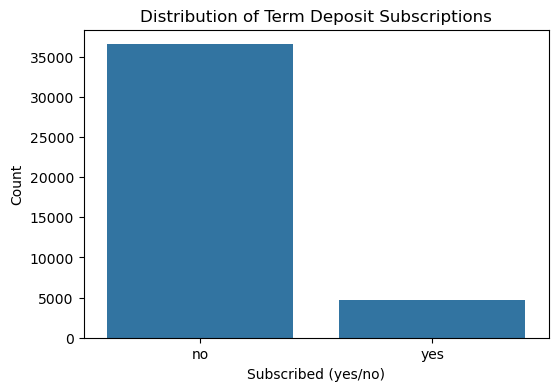

In [48]:
bank_df.head()
plt.figure(figsize=(6,4))
sns.countplot(data=bank_df, x='y')
plt.title('Distribution of Term Deposit Subscriptions')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Count')
plt.show()

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [49]:
bank_df.info()
missing_values_notes = """
The dataset uses the string 'unknown' to represent missing values across 
columns rather than nulls (NaN). The following features had unknown (missing) values:
job, marital, education, default, housing, loan.
"""

coercion_notes = """
1. Categorical text features (job, marital, education, etc.) must be 
   one-hot encoded using pd.get_dummies() before modeling.
2. The 'pdays' column uses the numeric placeholder 999 to mean 'never contacted', 
   which should be handled as a categorical flag to avoid affecting numeric analysis.
"""

# Print to confirm
print("Analysis complete.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

Business Objective:
To maximize the efficiency and conversion rate of the bank's telemarketing campaigns for term deposits. By comparing different classification models (Logistic Regression, KNN, Decision Trees, and SVM), the goal is to identify the most accurate model to predict which customers are likely to subscribe. This allows the bank to target high-probability prospects precisely, minimizing operational phone call costs and optimizing agent resources.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [50]:
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = bank_df[bank_features]
y = bank_df['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [51]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
numerical_cols = ['age']

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [54]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [55]:
baseline_acc = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy to Beat (Majority Class 'no'): {baseline_acc:.4f}")

Baseline Accuracy to Beat (Majority Class 'no'): 0.8873


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [56]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_proc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Problem 9: Score the Model

What is the accuracy of your model?

In [57]:
lr_train_preds = lr_model.predict(X_train_proc)
lr_test_preds = lr_model.predict(X_test_proc)

print(f"Logistic Regression Train Accuracy: {accuracy_score(y_train, lr_train_preds):.4f}")
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, lr_test_preds):.4f}")

Logistic Regression Train Accuracy: 0.8873
Logistic Regression Test Accuracy: 0.8874


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [63]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

comparison_results = []

for name, clf in classifiers.items():
    start_time = time.time()
    clf.fit(X_train_proc, y_train)
    train_time = time.time() - start_time
    
    train_acc = clf.score(X_train_proc, y_train)
    test_acc = clf.score(X_test_proc, y_test)
    
    comparison_results.append({
        "Model": name,
        "Train Time (s)": train_time,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })
    
comparison_df = pd.DataFrame(comparison_results)
print("=== Problem 10: Baseline Model Comparisons ===")
print(comparison_df.to_string(index=False))

=== Problem 10: Baseline Model Comparisons ===
              Model  Train Time (s)  Train Accuracy  Test Accuracy
Logistic Regression        0.039492        0.887343       0.887351
                KNN        0.002765        0.891471       0.878207
      Decision Tree        0.077194        0.918837       0.863883
                SVM       42.195583        0.888315       0.887028


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Running Decision Tree Grid Search...
Running KNN Grid Search...

--- Optimization Results ---
Best Decision Tree Params: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Baseline DT Test Accuracy: 0.8639
Optimized DT Test Accuracy: 0.8868

Best KNN Params: {'n_neighbors': 15, 'weights': 'uniform'}
Baseline KNN Test Accuracy: 0.8782
Optimized KNN Test Accuracy: 0.8863


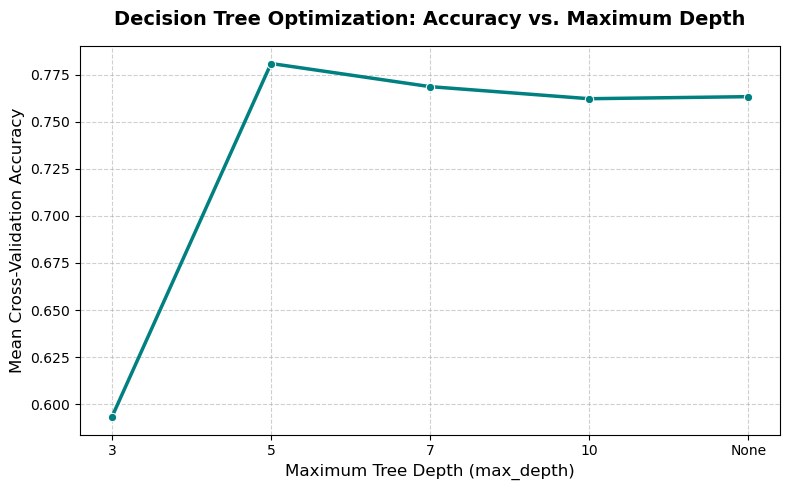

In [69]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_proc, y_train)

print("Running Decision Tree Grid Search...")
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, n_jobs=-1)
dt_grid.fit(X_train_proc, y_train)

print("Running KNN Grid Search...")
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, n_jobs=-1)
knn_grid.fit(X_train_proc, y_train)

print("\n--- Optimization Results ---")
print("Best Decision Tree Params:", dt_grid.best_params_)
print(f"Baseline DT Test Accuracy: {comparison_df.loc[comparison_df['Model'] == 'Decision Tree', 'Test Accuracy'].values[0]:.4f}")
print(f"Optimized DT Test Accuracy: {dt_grid.best_estimator_.score(X_test_proc, y_test):.4f}\n")

print("Best KNN Params:", knn_grid.best_params_)
print(f"Baseline KNN Test Accuracy: {comparison_df.loc[comparison_df['Model'] == 'KNN', 'Test Accuracy'].values[0]:.4f}")
print(f"Optimized KNN Test Accuracy: {knn_grid.best_estimator_.score(X_test_proc, y_test):.4f}")

cv_results = pd.DataFrame(dt_grid.cv_results_)

cv_results['param_max_depth'] = cv_results['param_max_depth'].fillna('None')
mean_scores = cv_results.groupby('param_max_depth')['mean_test_score'].mean().reset_index()

mean_scores['param_max_depth'] = mean_scores['param_max_depth'].astype(str)

plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_scores, x='param_max_depth', y='mean_test_score', marker='o', linewidth=2.5, color='teal')

plt.title('Decision Tree Optimization: Accuracy vs. Maximum Depth', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Maximum Tree Depth (max_depth)', fontsize=12)
plt.ylabel('Mean Cross-Validation Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### Questions